# Проект: Анализ объявлений о продаже недвижимости для определения рыночной стоимости квартир

**Цель:** Провести исследовательский анализ данных о продаже квартир в Санкт-Петербурге и прилегающих населённых пунктах, выявить факторы, влияющие на цену, и проверить статистические гипотезы.

**[Данные: real_estate_data.csv]**

### Описание данных:
- `total_images` — количество фотографий квартиры в объявлении
- `last_price` — цена на момент снятия объявления (руб.)
- `total_area` — общая площадь квартиры (м²)
- `first_day_exposition` — дата публикации объявления
- `rooms` — количество комнат
- `ceiling_height` — высота потолков (м)
- `floors_total` — общее количество этажей в доме
- `living_area` — жилая площадь (м²)
- `floor` — этаж квартиры
- `is_apartment` — апартаменты (boolean)
- `studio` — квартира-студия (boolean)
- `open_plan` — свободная планировка (boolean)
- `kitchen_area` — площадь кухни (м²)
- `balcony` — количество балконов
- `locality_name` — название населённого пункта / города
- `airports_nearest` — расстояние до ближайшего аэропорта (м)
- `cityCenters_nearest` — расстояние до центра города (м)
- `parks_around3000` — количество парков в радиусе 3 км
- `parks_nearest` — расстояние до ближайшего парка (м)
- `ponds_around3000` — количество водоёмов в радиусе 3 км
- `ponds_nearest` — расстояние до ближайшего водоёма (м)
- `days_exposition` — количество дней размещения объявления (от публикации до снятия)


## Пункт 1. Загрузка данных и первичная обработка

Задачи:

1.	Загрузите данные из CSV файла в датафрейм pandas. Сделайте копию дататфрейма.
2.	Изучите общую информацию о датафрейме: выведите первые 5 строк (head());
получите общую информацию (info()); проанализируйте описательную статистику (describe()).
3.	Проверьте явные дубликаты: найдите полностью идентичные строки во всём датафрейме; удалите их, сохранив только одно вхождение; запишите количество удалённых дубликатов.
4.	Постройте общую гистограмму для основных числовых столбцов: last_price, total_area, rooms, living_area, kitchen_area (используйте subplots).
5.	Найдите пропуски в ключевых столбцах: total_area, last_price, rooms, floors_total, balcony, ceiling_height, locality_name, first_day_exposition, city_centers_nearest.
6.	Проанализируйте процент пропусков по каждому столбцу:
рассчитайте долю пропусков для каждого из перечисленных столбцов: (количество пропусков / общее количество строк) * 100%; сравните с порогом в 5 %.
7.	Примените стратегию обработки пропусков в зависимости от участия столбца в дальнейшем анализе и доли пропущенных значений:
Если столбец НЕ участвует в дальнейшем анализе (не нужен для расчётов, графиков, статистических тестов), оставьте пропуски без изменений.
Если столбец участвует в анализе, обработайте пропуски по стратегии:

Столбцы (last_price, total_area, rooms, locality_name, ceiling_height):

	при пропусках ≤ 5 % — удалите строки;
	при пропусках > 5 % — заполните медианным/модальным значением (например, медианной ценой по району и количеству комнат).

Столбцы:

	balcony → заполните 0 - число (нет балкона);
	floors_total → при пропусках < 5 % удалите строки, иначе заполните медианным значением по району;
	city_centers_nearest → заполните медианным расстоянием для населённого пункта;
8.	Преобразуйте типы данных: столбец first_day_exposition (дата публикации) — в datetime; категориальные столбцы (locality_name, floor_type) — в тип object.
9.	После обработки пропусков:
проверьте итоговое количество строк в датафрейме;
сравните его с исходным размером набора данных;
зафиксируйте, сколько строк было удалено на этапе обработки пропусков(рассчитайте долю потери информации);
выведите список столбцов, в которых пропуски остались необработанными (с указанием процента пропусков).
Результат: очищенный датафрейм с удалёнными дубликатами, обработанными пропусками и преобразованными типами данных, готовый к анализу.

In [64]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
# Шаг 1: Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/colab đại học/môn python/Project tvor/real_estate_data.csv',sep ='\t')
# Шаг 2: Общий обзор данных
display(df.head())
print(df.info())
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

0
23699


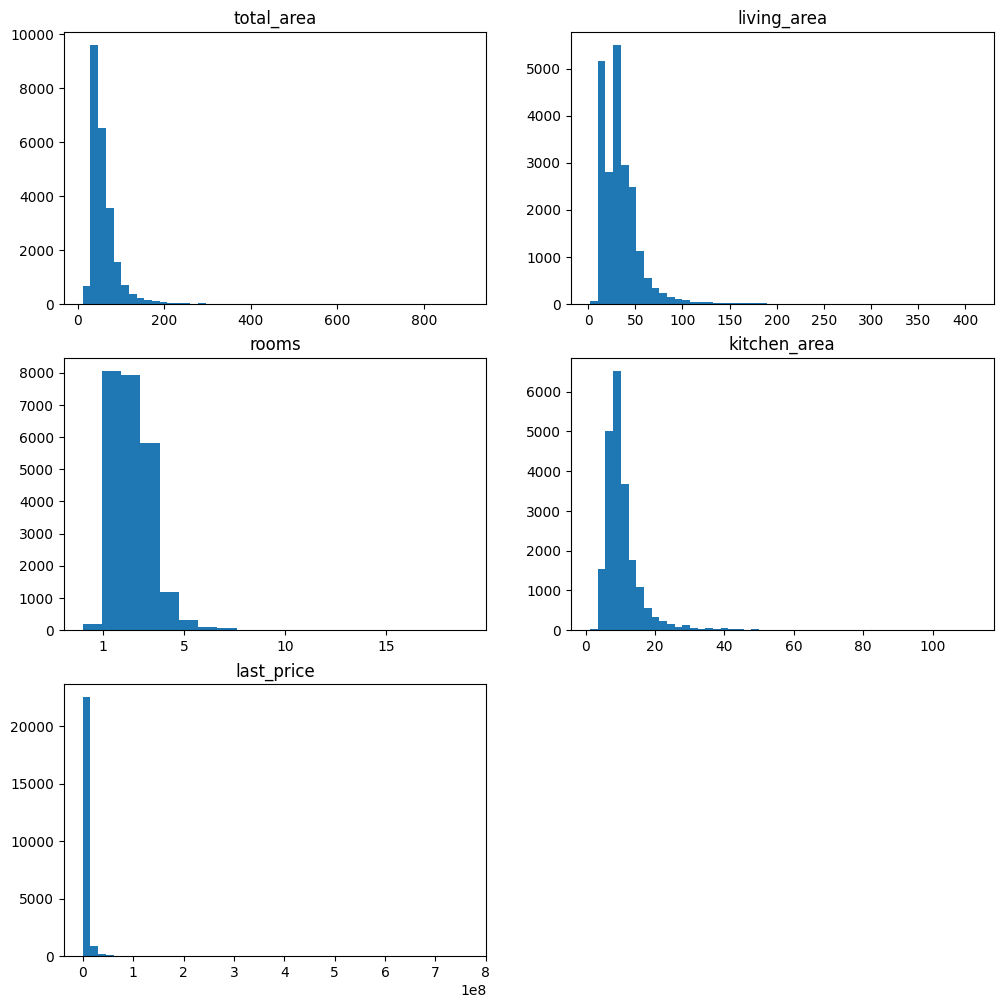

0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: last_price, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: total_area, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: rooms, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: floors_total, Length: 23699, dtype: bool
0         True
1        False
2        False
3        False
4         True
         ...  
23694     True
23695     True
23696     True
23697    False
23698     Tru

In [65]:
# Шаг 3: Проверка дублирующихся строк
df1= df.duplicated().sum() # количество дублирующихся строк
df = df.drop_duplicates()
print(df1)
print(len(df))
# Шаг 4: Гистограммы для основных числовых столбцов
fig, ax = plt.subplots(3,2,figsize =(12,12))
ax[0,0].hist(df['total_area'],bins = 50)
ax[1,0].hist(df['rooms'],bins=20)
ax[0,1].hist(df['living_area'],bins = 50)
ax[1,1].hist(df['kitchen_area'],bins = 50)
ax[2,0].hist(df['last_price'],bins=50)
ax[2,1].set_visible(False)
ax[0,0].set_title('total_area')
ax[1,0].set_title('rooms')
ax[0,1].set_title('living_area')
ax[1,1].set_title('kitchen_area')
ax[1,0].set_xticks([1,5,10,15])
ax[2,0].set_title('last_price')
plt.show()

# Шаг 5: Поиск пропущенных значений
print(df['last_price'].isnull())
print(df['total_area'].isnull())
print(df['rooms'].isnull())
print(df['floors_total'].isnull())
print(df['balcony'].isnull())
print(df['ceiling_height'].isnull())
print(df['locality_name'].isnull())
print(df['first_day_exposition'].isnull())
print(df['cityCenters_nearest'].isnull())

# Шаг 6: Расчёт доли пропущенных значений (%) по каждому столбцу
print('last_price',df['last_price'].isnull().sum()/ len(df)*100)
print('total_area',df['total_area'].isnull().sum()/ len(df)*100)
print('rooms',df['rooms'].isnull().sum()/ len(df)*100)
print('floors_total',df['floors_total'].isnull().sum()/ len(df)*100)
print('balcony',df['balcony'].isnull().sum()/ len(df)*100)
print('ceiling_height',df['ceiling_height'].isnull().sum()/ len(df)*100)
print('locality_name',df['locality_name'].isnull().sum()/ len(df)*100)
print('first_day_exposition',df['first_day_exposition'].isnull().sum()/ len(df)*100)
print('cityCenters_nearest',df['cityCenters_nearest'].isnull().sum()/ len(df)*100)

После расчёта доли пропущенных значений по 9 столбцам, сравним с порогом 5%:

**Столбцы с долей пропусков < 5%** (строки можно удалить): `last_price`, `total_area`, `rooms`, `floors_total`, `locality_name`, `first_day_exposition`

**Столбцы с долей пропусков > 5%** (необходимо заполнить): `balcony`, `ceiling_height`, `cityCenters_nearest`


In [66]:
# Шаг 7: Обработка пропущенных значений
df.dropna(subset=['total_area', 'last_price', 'rooms', 'floors_total', 'locality_name', 'first_day_exposition','days_exposition'], inplace=True)
df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())
df['balcony'] = df['balcony'].fillna(0)
df['cityCenters_nearest'] = df['cityCenters_nearest'].fillna(df['cityCenters_nearest'].median())

# Шаг 8: Преобразование типов данных
df['first_day_exposition']=pd.to_datetime(df['first_day_exposition'],errors='coerce',format ='mixed',yearfirst=True)
df['locality_name'] = df['locality_name'].astype('object')
# нет столбца floor type
# Шаг 9: Итоговая статистика после обработки
first_df = pd.read_csv('/content/drive/MyDrive/colab đại học/môn python/Project tvor/real_estate_data.csv',sep ='\t')
deleted_rows = len(first_df) - len(df)
percent_rows = (deleted_rows / len(first_df)) * 100

print('Шаг 9')
print(f"Исходное количество строк: {len(first_df)}")
print(f"Количество строк после обработки: {len(df)}")
print(f"Удалено строк: {deleted_rows}")
print(f"Доля потерь: {round(percent_rows,2)}%")

df2 = df.isnull().sum() / len(df) * 100
print(df2) # ещё 8 столбцов с пропусками, которые не удаляем

Шаг 9
Исходное количество строк: 23699
Количество строк после обработки: 20394
Удалено строк: 3305
Доля потерь: 13.95%
total_images             0.000000
last_price               0.000000
total_area               0.000000
first_day_exposition     0.000000
rooms                    0.000000
ceiling_height           0.000000
floors_total             0.000000
living_area              8.188683
floor                    0.000000
is_apartment            87.815044
studio                   0.000000
open_plan                0.000000
kitchen_area             9.919584
balcony                  0.000000
locality_name            0.000000
airports_nearest        22.844954
cityCenters_nearest      0.000000
parks_around3000        22.737080
parks_nearest           66.230264
ponds_around3000        22.737080
ponds_nearest           61.645582
days_exposition          0.000000
dtype: float64


## Пункт 2. Работа с датами и создание новых признаков

**Задачи:**

1. Добавить в df следующие столбцы:
- `year` — год публикации объявления;
- `month` — месяц публикации объявления;
- `weekday` — день недели (0 — понедельник, 6 — воскресенье);
- `day` — день публикации объявления.

2. Построить графики распределения (столбчатые) публикаций объявлений по: году, месяцу, дню недели.

3. Добавить в df другие важные столбцы:
- цена за квадратный метр (значение актива делится на общую площадь, затем округляется до двух знаков после запятой) (`price_per_sqm`);
- расстояние до центра города в км (перевести из м в км и округлить до целого) (`distance_km`);
- `floor_type`: «первый этаж» (если `floor` = 1), «последний этаж» (если `floor` = `floors_total`), «другой» (все остальные случаи).


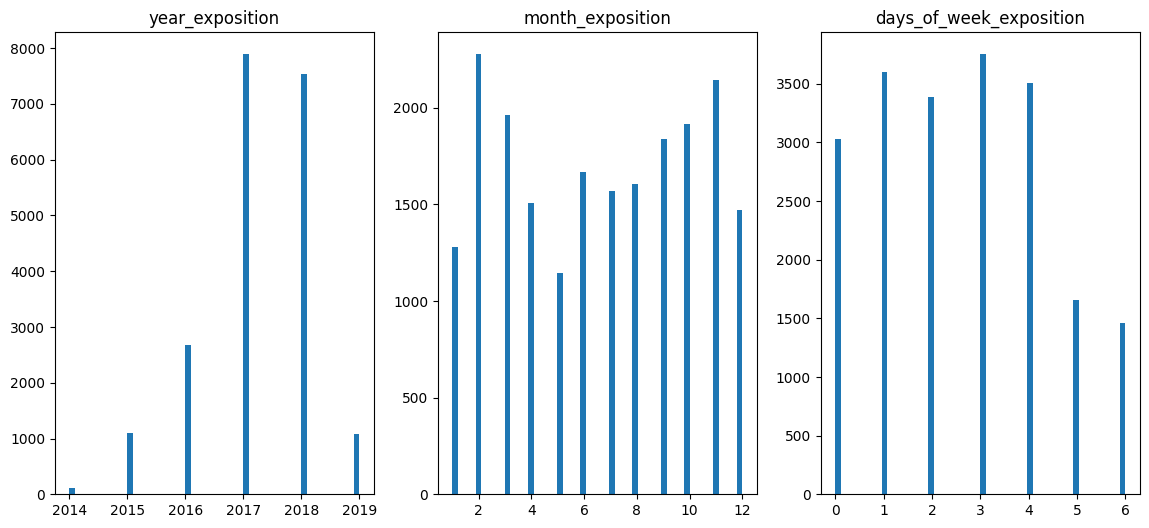

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,year_exposition,month_exposition,days_of_week_exposition,day_of_month_exposition,price_per_sqm,distance_km,floor_type
1,7,3350000.0,40.40,2018-12-04,1,2.65,11.0,18.6,1,NaN,...,0.0,NaN,81.0,2018,12,1,4,82920.79,19.0,первый этаж
2,10,5196000.0,56.00,2015-08-20,2,2.65,5.0,34.3,4,NaN,...,2.0,574.0,558.0,2015,8,3,20,92785.71,14.0,другой
3,0,64900000.0,159.00,2015-07-24,3,2.65,14.0,NaN,9,NaN,...,3.0,234.0,424.0,2015,7,4,24,408176.10,7.0,другой
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.0,13,NaN,...,1.0,48.0,121.0,2018,6,1,19,100000.00,8.0,другой
5,10,2890000.0,30.40,2018-09-10,1,2.65,12.0,14.4,5,NaN,...,NaN,NaN,55.0,2018,9,0,10,95065.79,13.0,другой
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23691,11,9470000.0,72.90,2016-10-13,2,2.75,25.0,40.3,7,NaN,...,1.0,806.0,519.0,2016,10,3,13,129903.98,4.0,другой
23692,2,1350000.0,30.00,2017-07-07,1,2.65,5.0,17.5,4,NaN,...,NaN,NaN,413.0,2017,7,4,7,45000.00,13.0,другой
23693,9,4600000.0,62.40,2016-08-05,3,2.60,9.0,40.0,8,NaN,...,1.0,675.0,239.0,2016,8,4,5,73717.95,34.0,другой
23695,14,3100000.0,59.00,2018-01-15,3,2.65,5.0,38.0,4,NaN,...,NaN,NaN,45.0,2018,1,0,15,52542.37,13.0,другой


In [67]:
# Шаг 1: Добавление временных признаков
df['year_exposition']  = df['first_day_exposition'].dt.year
df['month_exposition']  = df['first_day_exposition'].dt.month
df['days_of_week_exposition']  = df['first_day_exposition'].dt.day_of_week
df['day_of_month_exposition']  = df['first_day_exposition'].dt.day

# Шаг 2: Графики распределения по году, месяцу и дню недели
fig,ax=plt.subplots(1,3,figsize=(14,6))
ax[0].hist(df['year_exposition'],bins =50)
ax[1].hist(df['month_exposition'],bins =50)
ax[2].hist(df['days_of_week_exposition'],bins =50)

ax[0].set_title('year_exposition')
ax[1].set_title('month_exposition')
ax[2].set_title('days_of_week_exposition')
plt.show()

# Шаг 3: Добавление производных признаков
df['price_per_sqm']= round((df['last_price']/ df['total_area']),2)
df['distance_km']=round((df['cityCenters_nearest']/1000),0)
conditions = [df['floor'] == 1, df['floor'] == df['floors_total']] # список из 2 условий
choices = ['первый этаж', 'последний этаж']
df['floor_type'] = np.select(conditions, choices, default='другой') # параметр default для случаев, не совпадающих с условиями
display(df)


## Результаты выполнения пункт 2

После добавления временны́х признаков, цены за квадратный метр, расстояния до центра и типа этажа, а также построения графиков распределения, получены следующие результаты:

1. **По годам:** Наибольшее количество объявлений приходится на 2017 и 2018 годы. В остальные годы объявлений значительно меньше.

2. **По месяцам:** Пик активности публикаций наблюдается в весенние (февраль, март, апрель) и осенние (октябрь, ноябрь) месяцы.

3. **По дням недели:** Объявления чаще всего публикуются в будние дни, реже всего — в выходные (суббота, воскресенье).

4. **Цена за квадратный метр (`price_per_sqm`):** Вычисленный показатель будет использован в последующих анализах.

5. **Расстояние до центра (`distance_km`):** Переведено из метров в километры, что упрощает группировку квартир по удалённости от центра.

6. **Тип этажа (`floor_type`):** Разделён на три категории: «первый этаж», «последний этаж», «другой». Этот признак поможет проверить гипотезы о влиянии расположения этажа на цену продажи.

Все новые признаки успешно добавлены, типы данных корректны, пропущенных значений нет. Данные готовы к следующему этапу — исследовательскому анализу в Разделе 3.


## Пункт 3, Часть 3.1. Разведочный анализ данных (EDA)

1. Построить гистограммы или диаграммы размаха (boxplot) для анализа распределения и выявления аномалий в столбцах: `total_area`, `last_price`, `price_per_sqm`, `distance_km`, `ceiling_height`.

2. Обработать аномалии:
- Удалить строки с `total_area` < 10 или > 200 м²;
- Удалить строки с `last_price` < 1e6 или > 50e6 руб.;
- Удалить строки с аномально низкой/высокой высотой потолков: `ceiling_height` < 2.2 или > 3.5 м.

3. Вычислить среднее и медиану `days_exposition`.

Описать результаты выполнения в ячейке markdown.


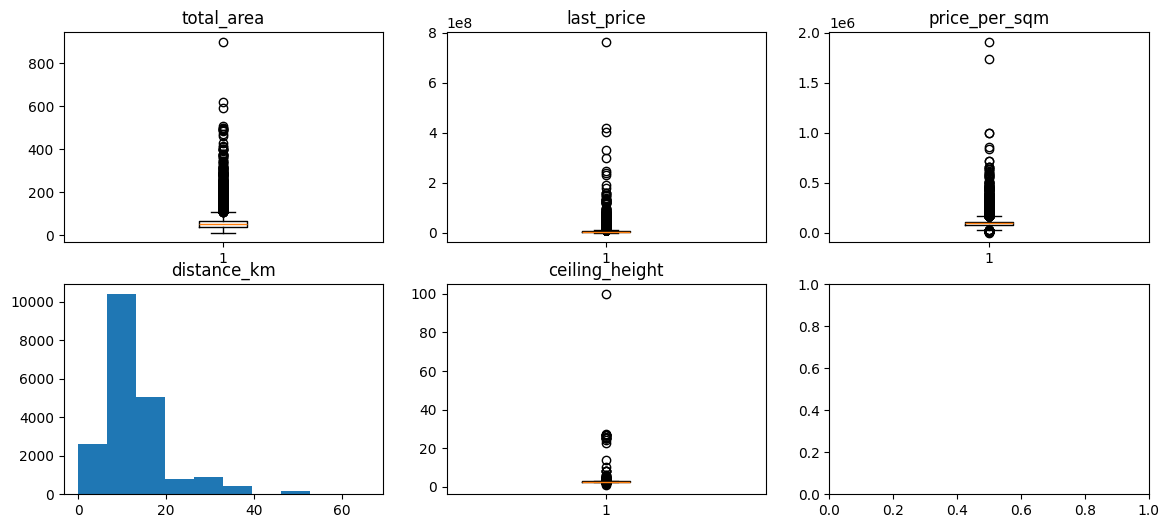

178.7137924030063
94.0


In [68]:
# Шаг 1: Визуализация распределений и аномалий
fig,ax = plt.subplots(2,3,figsize = (14,6))
ax[0,0].boxplot(df['total_area'])
ax[0,1].boxplot(df['last_price'])
ax[0,2].boxplot(df['price_per_sqm'])
ax[1,0].hist(df['distance_km'])
ax[1,1].boxplot(df['ceiling_height'])

ax[0,0].set_title('total_area')
ax[0,1].set_title('last_price')
ax[0,2].set_title('price_per_sqm')
ax[1,0].set_title('distance_km')
ax[1,1].set_title('ceiling_height')
plt.show()

# Шаг 2: Удаление выбросов
# Удалить строки с total_area < 10 или > 200 м²
df = df[(df['total_area']>10) & (df['total_area']<200)]
# Удалить строки с last_price < 1e6 или > 50e6 руб.
df = df[(df['last_price']>1e6) & (df['last_price']<50e6)]
# Удалить строки с аномальной высотой потолков: ceiling_height < 2.2 или > 3.5 м
df = df[(df['ceiling_height']>2.2) & (df['ceiling_height']<3.5)]

# Шаг 3: Среднее и медиана days_exposition
print(df['days_exposition'].mean()) # 178
print(df['days_exposition'].median()) # 94

После построения boxplot и гистограмм обнаружены аномалии в 3 столбцах: `total_area`, `last_price`, `ceiling_height`. После удаления выбросов согласно инструкции графики boxplot стали более аккуратными и корректными.

Среднее значение `days_exposition` значительно превышает медиану (почти в два раза) — это свидетельствует о правостороннем распределении (есть выбросы с очень долгим сроком размещения объявления).


### Часть 3.2. Анализ факторов, влияющих на цену, и визуализация

1. **Анализ динамики цен:**
- Построить график цен (`last_price`) по годам;
- Построить график средней цены за квадратный метр (`price_per_sqm`) по месяцам (отдельно для каждого года);
- Сравнить количество объявлений по годам и месяцам (тепловая карта — heatmap).

2. **Влияние количества комнат и типа этажа на цену за м²:**
- Построить диаграмму «скрипка» (`sns.violinplot`) цены за квадратный метр (`price_per_sqm`) в зависимости от количества комнат (`rooms`);
- Использовать параметр `hue` для разбивки по типу этажа (`floor_type`), чтобы видеть распределение цены по двум факторам одновременно;
- Настроить прозрачность (`alpha`) и добавить точки данных (`inner='point'` или `inner='stick'`) для лучшей читаемости.

3. Вычислить корреляцию `last_price` с `total_area`, `rooms`, `kitchen_area`, `ceiling_height`.

4. Определить 5 населённых пунктов с наибольшим количеством объявлений.

5. Построить столбчатую диаграмму средней цены за квадратный метр для этих населённых пунктов.

6. Проанализировать зависимость `price_per_sqm` от `distance_km`:
- Сгруппировать данные по `distance_km`;
- Вычислить среднюю цену за квадратный метр для каждого километра;
- Построить линейный график.

Описать результаты анализа факторов цены и визуализации в ячейке markdown.


   last_year_exposition    last_price
0                  2016  5.736813e+06
1                  2017  5.532806e+06
2                  2018  5.468888e+06
3                  2019  6.063750e+06


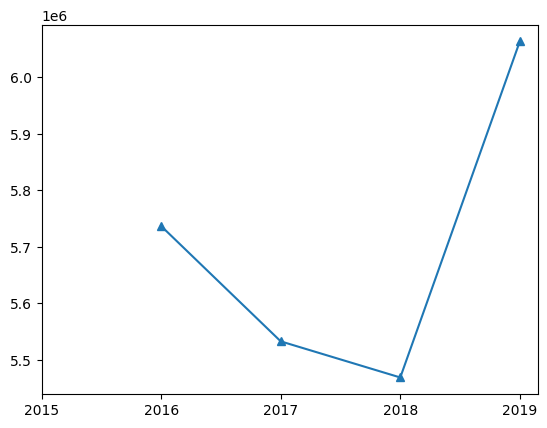

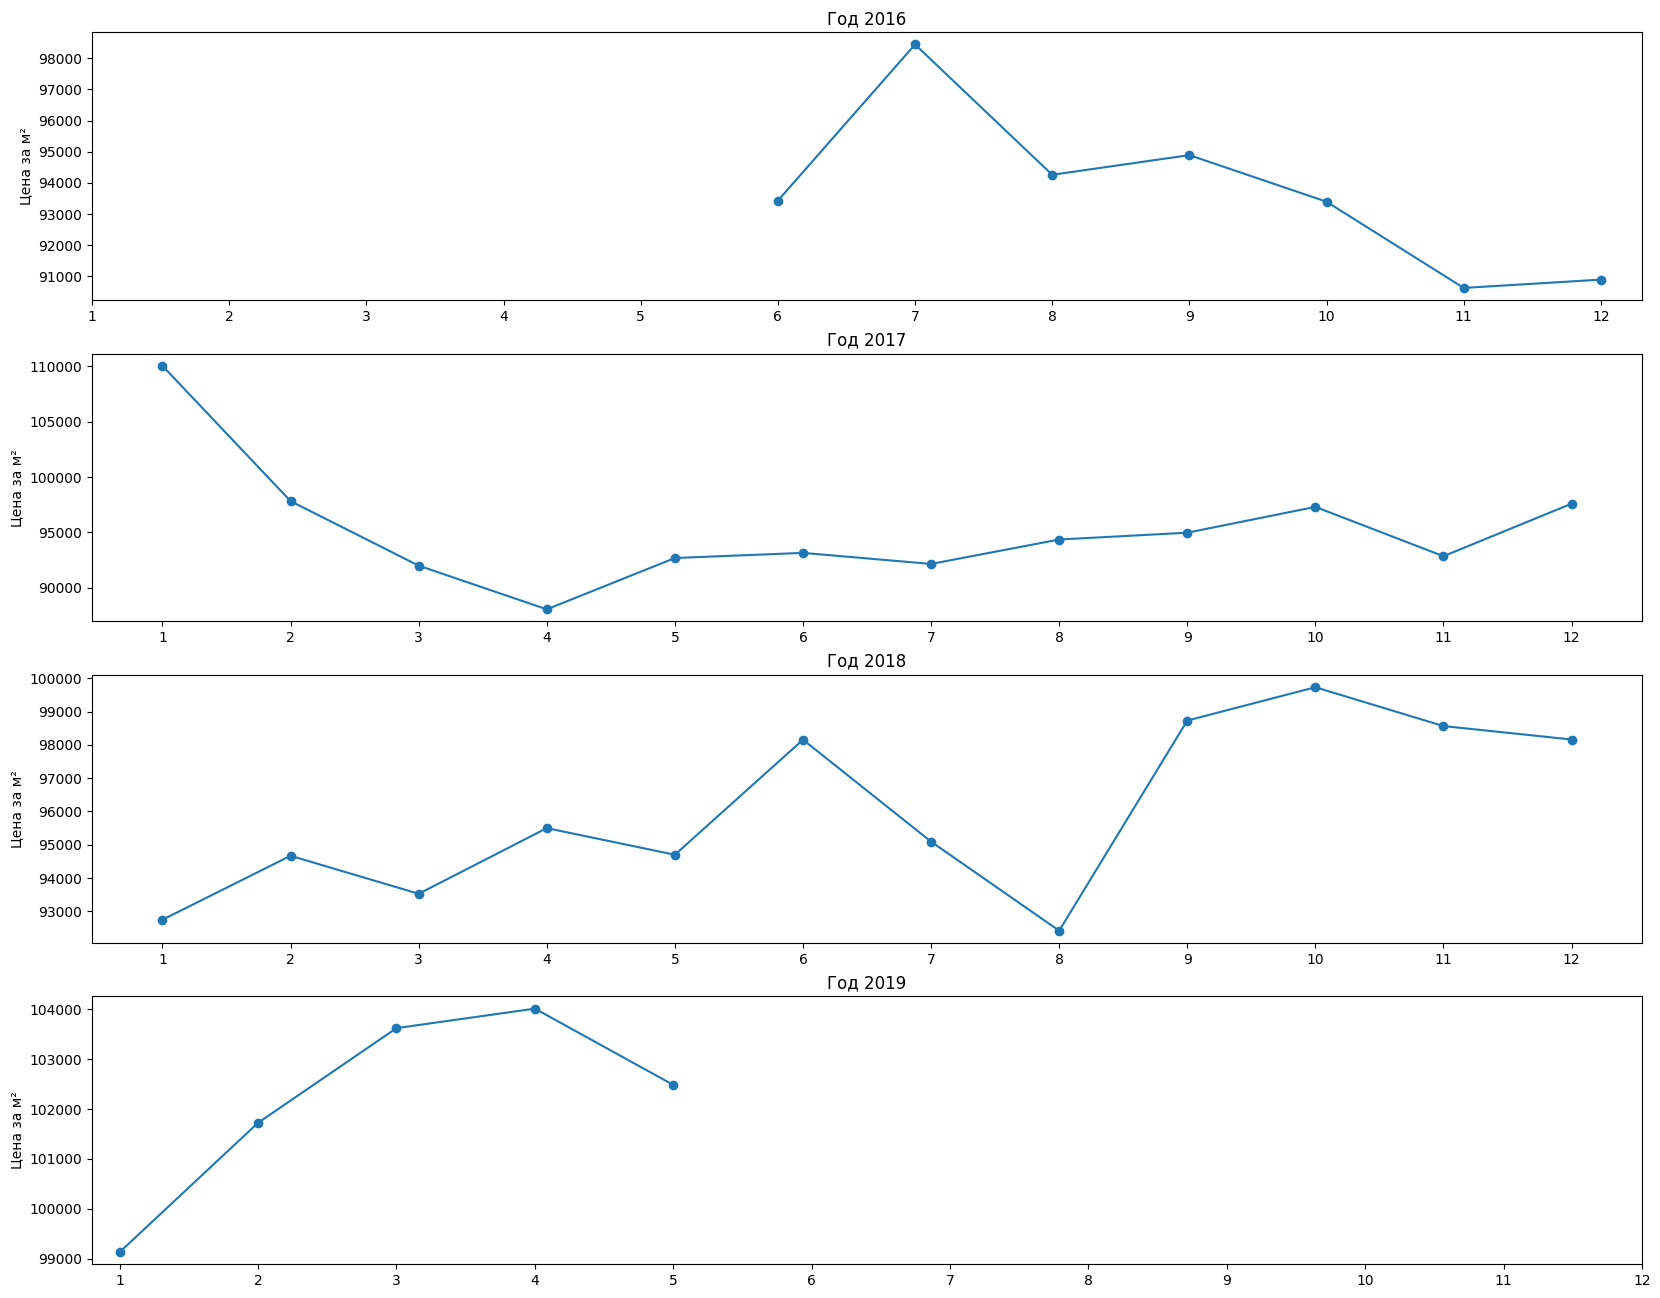

In [69]:
# Шаг 1а: Динамика цен по годам
df['last_day_exposition'] = df['first_day_exposition'] + pd.to_timedelta(df['days_exposition'],unit='D')
df['last_year_exposition'] = df['last_day_exposition'].dt.year
price_pivot = df.pivot_table(
    values='last_price', # вычисление по last_price
    index='last_year_exposition',
    aggfunc='mean'
).reset_index()
print(price_pivot)
plt.plot(price_pivot['last_year_exposition'],price_pivot['last_price'],marker ='^')
plt.xticks(range(2015,2020))
plt.show()

# Шаг 1б: Средняя цена за м² по месяцам для каждого года
df['last_month_exposition'] = df['last_day_exposition'].dt.month
avg_price = df.groupby(['last_year_exposition', 'last_month_exposition'])['price_per_sqm'].mean().reset_index()
years=range(2016,2020)
fig,ax = plt.subplots(4,1,figsize=(20,16))
for i, year in enumerate(years):
    year_data = avg_price[avg_price['last_year_exposition'] == year]
    ax[i].plot(year_data['last_month_exposition'], year_data['price_per_sqm'], marker='o')
    ax[i].set_title(f'Год {year}')
    ax[i].set_ylabel('Цена за м²')
    ax[i].set_xticks(range(1, 13))
plt.show()

last_month_exposition    1    2     3    4    5    6    7    8    9    10  \
last_year_exposition                                                        
2016                      0    0     0    0    0  232  505  356  258  196   
2017                    156  133   168  186  277  364  446  410  532  711   
2018                   1064  901  1046  910  702  481  536  778  903  980   
2019                    603  563   654  958   57    0    0    0    0    0   

last_month_exposition    11   12  
last_year_exposition              
2016                    121   92  
2017                    761  766  
2018                   1014  872  
2019                      0    0  


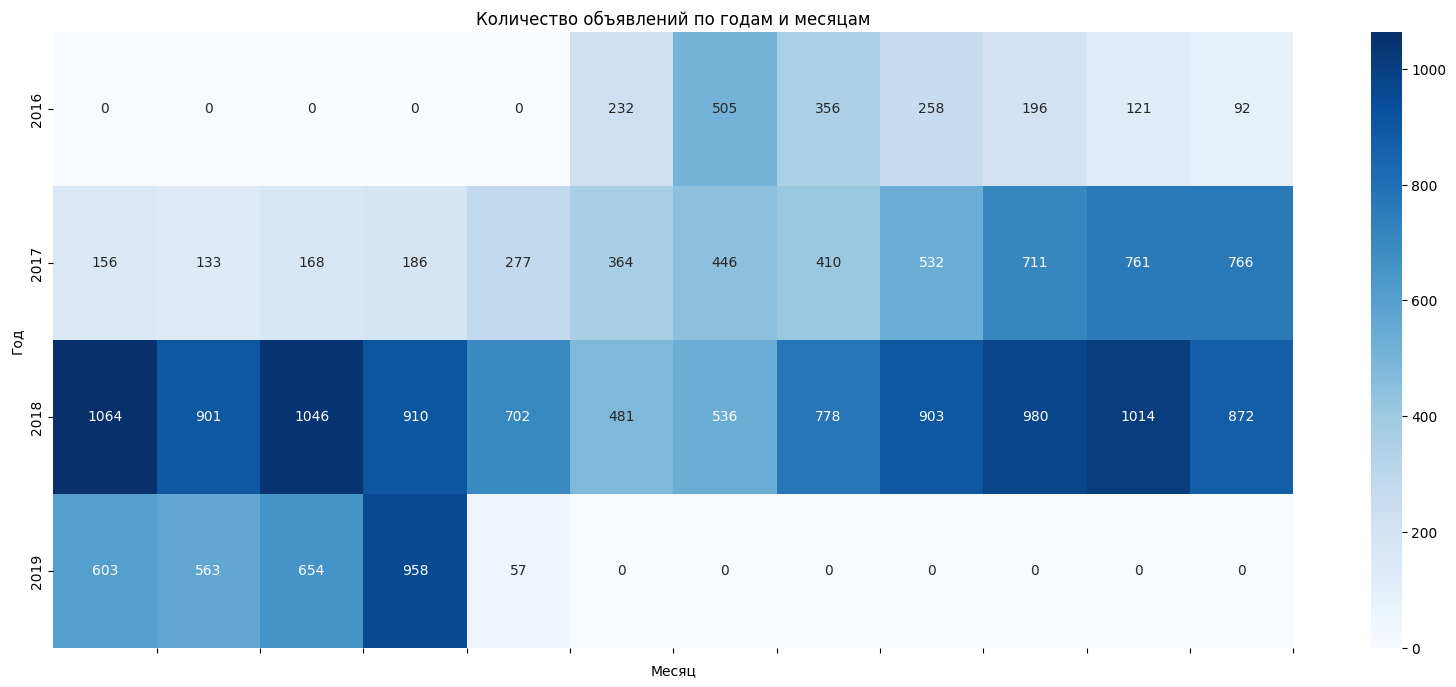

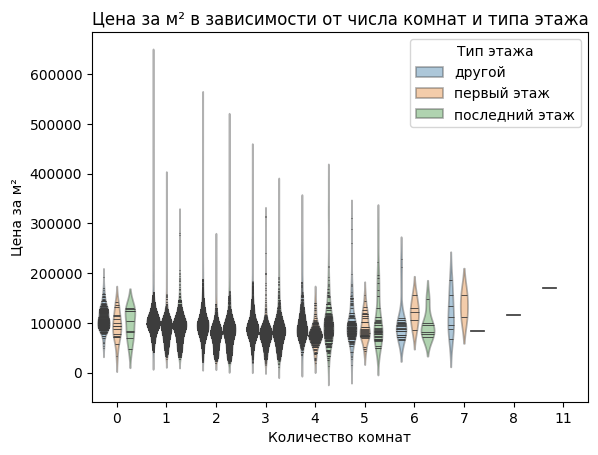

total_area        0.763115
rooms             0.467566
kitchen_area      0.581270
ceiling_height    0.389738
dtype: float64


In [70]:
# Шаг 1в: heatmap количества объявлений по годам и месяцам
pivot_counts = df.pivot_table( # строки — год снятия, столбцы — месяц снятия, значения — количество объявлений
    index='last_year_exposition',
    columns='last_month_exposition',
    values='last_price',
    aggfunc='count'
).fillna(0).astype(int)
print(pivot_counts)
plt.figure(figsize=(20, 8))
sns.heatmap(pivot_counts,annot=True,fmt='d',cmap='Blues')
plt.title('Количество объявлений по годам и месяцам')
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.xticks(ticks=range(1,13))
plt.show()
# Шаг 2: Диаграмма «скрипка» цены за м² по комнатам и типу этажа
sns.violinplot(data= df,x ='rooms',y= 'price_per_sqm',hue = 'floor_type',alpha = 0.4,inner ='stick')
plt.title('Цена за м² в зависимости от числа комнат и типа этажа')
plt.xlabel('Количество комнат')
plt.ylabel('Цена за м²')
plt.legend(title='Тип этажа')
plt.show()
# Шаг 3: Корреляция last_price с основными признаками
cor = df[["total_area", "rooms", "kitchen_area", "ceiling_height"]].corrwith(df['last_price'])
print(cor)


**Вывод 3.2:**

**#1** По графику `last_price` по годам видно, что в 2017–2018 гг. количество объявлений было высоким, однако средняя цена продажи ниже, чем в 2015 и в 2019гг. Это может быть связано с тем, что данные за 2015 и 2019 годы охватывают только 6 месяцев.

График средней цены за м² по месяцам показывает общую тенденцию к росту в конце года — примерно в сентябре–октябре (осенью).

Тепловая карта количества объявлений подтверждает, что 2017 и 2018 гг. значительно превосходят остальные по активности.

**#2** Описание диаграммы «скрипка» приведено отдельно в пункт 4 (violin plot).

**#3** Только `total_area` имеет достаточно высокую корреляцию с `last_price` (r = 0.7); остальные признаки коррелируют значительно слабее.


       locality_name  count           mean
32   Санкт-Петербург  13123  109534.215509
240   посёлок Мурино    513   85711.577856
270   посёлок Шушары    406   77846.547660
3         Всеволожск    335   68515.952209
13           Колпино    307   74763.339316


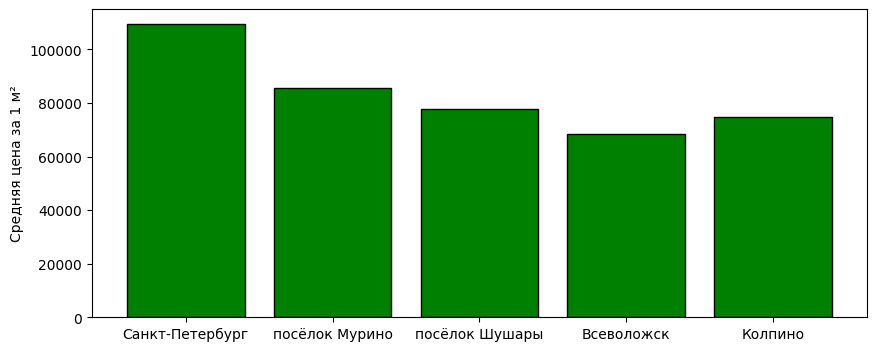

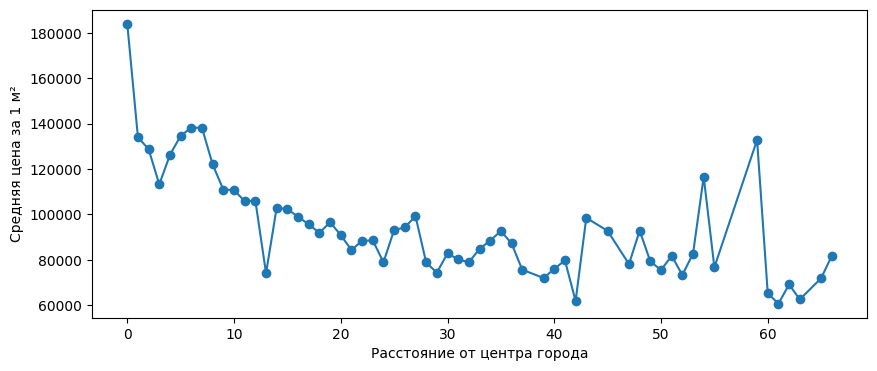

In [71]:
# Шаг 4: Топ-5 населённых пунктов по количеству объявлений
count_by_location = df.pivot_table(index = 'locality_name' , values='price_per_sqm', aggfunc={'price_per_sqm':['count','mean']}).reset_index()
count_by_location.sort_values(by='count',inplace=True, ascending = False)
top_by_location = (count_by_location.head(5))
print(top_by_location)
# Шаг 5: Средняя цена за м² для топ-5 населённых пунктов
plt.figure(figsize = (10,4))
plt.bar(top_by_location['locality_name'],top_by_location['mean'],color = 'g',edgecolor ='black')
plt.ylabel('Средняя цена за 1 м²')
plt.show()
# Шаг 6: Зависимость price_per_sqm от distance_km
price_by_distance = df.pivot_table(index = 'distance_km', values = 'price_per_sqm',aggfunc = 'mean').reset_index()
plt.figure(figsize=(10,4))
plt.plot(price_by_distance['distance_km'],price_by_distance['price_per_sqm'],marker = 'o')
plt.ylabel('Средняя цена за 1 м²')
plt.xlabel('Расстояние от центра города')
plt.show()


**Вывод #4:** Топ-5 населённых пунктов по количеству объявлений:
- Санкт-Петербург — 15 059
- посёлок Мурино — 518
- посёлок Шушары — 438
- Всеволожск — 393
- Пушкин — 355

**Вывод #5:** Примечательно, что г. Пушкин имеет относительно небольшое число объявлений, однако цена за м² здесь близка к уровню Санкт-Петербурга — наиболее активного и дорогого рынка.

**Вывод #6:** Средняя цена за м² снижается по мере удаления от центра. В центре (0 км): максимальная цена ~119 000 руб./м². В диапазоне 0–5 км цена резко падает до ~40 000–50 000 руб./м². Однако после 40 км цена незначительно растёт, что может объясняться повышенным спросом на загородную недвижимость под строительство дач и коттеджей.

**Общий вывод:** Чем дальше от центра, тем ниже и стабильнее цена. Каждый дополнительный километр от центра сопровождается заметным снижением цены, особенно в первых 5 км.


## Пункт 4. Статистический анализ: Z-тест и t-тест

### Часть 4.1. Сравнение долей: Доля квартир со свободной планировкой (open plan) в домах от 15 этажей выше, чем в домах до 5 этажей

- **H₀:** Доли равны.
- **H₁:** Доля выше в высотных домах.

**Обоснование:** Современные многоэтажные жилые комплексы, как правило, предлагают квартиры с гибкой планировкой.

**Задачи:**

1. Создать бинарную переменную для свободной планировки: `open_plan_binary` = 1, если `open_plan` = True, иначе 0.
2. Отфильтровать две группы:
- Группа A (низкоэтажные дома): `floors_total` ≤ 5
- Группа B (высотные дома): `floors_total` ≥ 10
3. Перед тестированием удалить строки с пропущенными значениями в столбце `open_plan_binary` (использовать `dropna()`).
4. Провести Z-тест (`proportions_ztest`):
- `count` — массив из двух значений: количество квартир с признаком в группе A и группе B;
- `nobs` — массив из двух значений: общее число квартир в группе A и группе B;
- `alternative = 'larger'` (односторонний тест: доля в группе B выше).
5. Интерпретировать результат (p-value < 0.05 → отклонить H₀).
6. Построить столбчатую диаграмму с двумя столбцами.

### Часть 4.2. Сравнение средних цен

**Гипотеза:** Средняя цена за квадратный метр в Санкт-Петербурге выше, чем в других населённых пунктах.

- **H₀:** Средние цены равны.
- **H₁:** Средняя цена в Санкт-Петербурге выше.

**Задачи:**

1. Разделить данные на две группы:
- Санкт-Петербург: `locality_name == 'Санкт-Петербург'`
- Остальные населённые пункты.
2. Перед тестированием удалить строки с пропущенными значениями в столбце `price_per_sqm` (использовать `dropna()`).
3. Проверить нормальность распределения (с помощью гистограммы) и равенство дисперсий (необязательно).
4. Провести t-тест (`ttest_ind` из `scipy.stats`, параметр `alternative='greater'`).
5. Интерпретировать результат.
6. Визуализировать сравнение средних цен (ящик с усами — box plot).

**Результат:** Статистически обоснованные выводы по двум гипотезам с графиками.


p-value: 6.814337673780134e-08


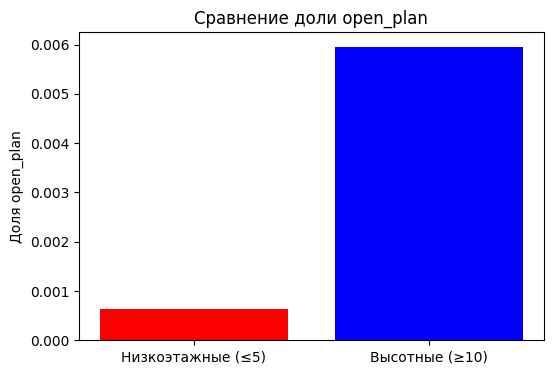

In [72]:
from statsmodels.stats import proportion
# Часть 4.1
# Шаг 1: Создание бинарной переменной
condition = [df['open_plan']==True]
df['open_plan_binary'] =np.select(condition,[1],default = 0)
# Шаг 2: Формирование двух групп
low_floor = df[(df['floors_total']<=5)]
high_floor =  df[(df['floors_total']>=10)]
# Шаг 3: Удаление строк с пропусками в столбце `open_plan_binary`
low_floor = low_floor.dropna(subset= 'open_plan_binary').reset_index()
high_floor=  high_floor.dropna(subset= 'open_plan_binary').reset_index()
# Шаг 4: Z-тест (proportions_ztest)
count_low_floor = low_floor['open_plan_binary'].sum()
count_high_floor = high_floor['open_plan_binary'].sum()
z,p = proportion.proportions_ztest(count=[count_high_floor,count_low_floor],
                            nobs=[len(high_floor),len(low_floor)],alternative = 'larger') # первая группа больше второй
print('p-value:',p)
# Шаг 5: Вывод
# Шаг 6: Столбчатая диаграмма
rates = [count_low_floor / len(low_floor), count_high_floor / len(high_floor)]
labels = ['Низкоэтажные (≤5)', 'Высотные (≥10)']
plt.figure(figsize=(6, 4))
plt.bar(labels, rates, color=['red', 'blue'])
plt.ylabel('Доля open_plan')
plt.title('Сравнение доли open_plan')
plt.show()


**Вывод 4.1:** p-value = 2.756e-08 < 0.05 → H₀ отклоняется. Есть достаточно оснований утверждать, что доля квартир со свободной планировкой в высотных современных домах статистически значимо выше, чем в малоэтажных (где, как правило, используется фиксированная планировка).


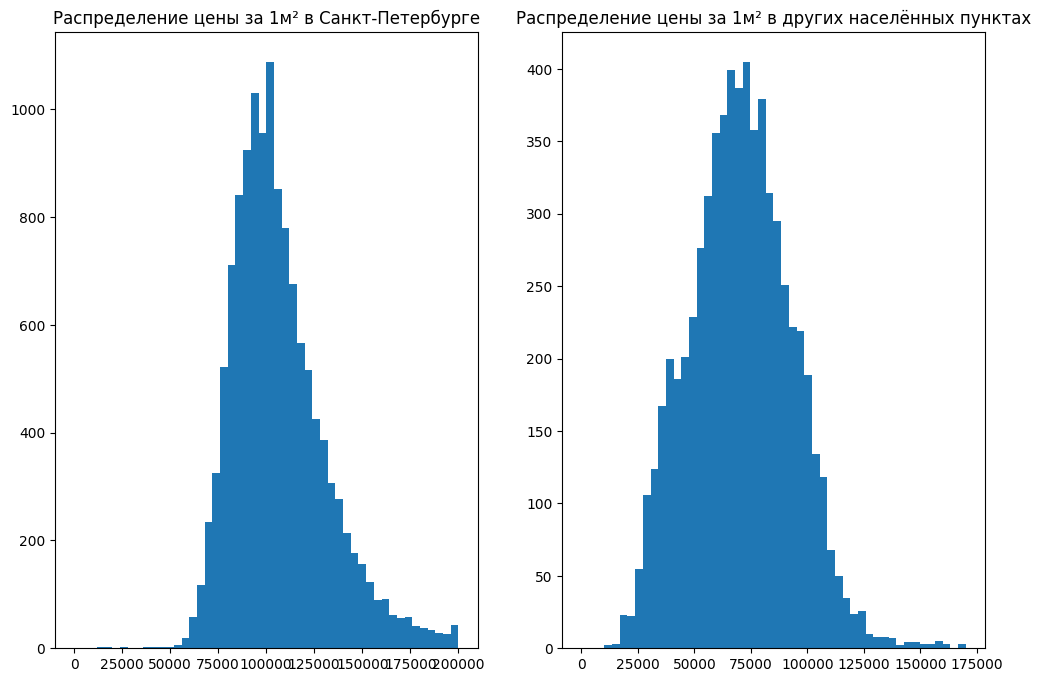

p-value для СПб: 8.99863167583533e-84 
 p-value для остальных городов: 3.21939238005832e-50
p-value критерия Левена: 5.95318385057533e-17
p-value для двухвыборочного t-теста: 0.0


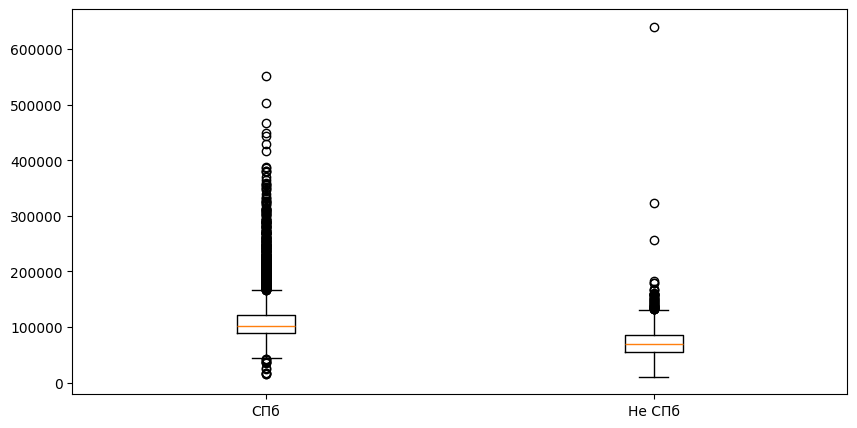

In [73]:
from scipy import stats as st
# Часть 4.2
# Шаг 1: Формирование двух групп
saint = df[(df['locality_name']=='Санкт-Петербург')]
not_saint =  df[(df['locality_name'] != 'Санкт-Петербург')]
# Шаг 2: Удаление строк с пропусками в столбце `price_per_sqm`
saint = saint.dropna(subset=['price_per_sqm']).reset_index()
not_saint=  not_saint.dropna(subset=['price_per_sqm']).reset_index()
# Шаг 3: Проверка нормальности распределения
fig,ax = plt.subplots(1,2,figsize = (12,8))
ax[0].hist(saint['price_per_sqm'],bins= 50,range=(0,200000))
ax[1].hist(not_saint['price_per_sqm'],bins = 50,range=(0,170000))
ax[0].set_title('Распределение цены за 1м² в Санкт-Петербурге')
ax[1].set_title('Распределение цены за 1м² в других населённых пунктах')
plt.show()
# нормальность только в указанном диапазоне
# Способ 2: критерий Шапиро-Уилка
s1,p1 = st.shapiro(x= saint['price_per_sqm'])
s2,p2 = st.shapiro(x= not_saint['price_per_sqm'])
print('p-value для СПб:',p1,'\n','p-value для остальных городов:',p2)
# p-value обоих < 0.05 → вывод: распределения ненормальные
# Проверка равенства дисперсий
s3, p3 = st.levene(saint['price_per_sqm'], not_saint['price_per_sqm'])
print('p-value критерия Левена:',p3) # p-value < 0.05 → дисперсии различаются

# Шаг 4: t-тест (если оба условия не выполнены — формально t-тест двух выборок не применяется,
# но выполняем согласно заданию)
t,p=st.ttest_ind(saint['price_per_sqm'],not_saint['price_per_sqm'],alternative='greater') # СПб больше
print('p-value для двухвыборочного t-теста:',p)
# Шаг 5: Вывод
# p-value ≈ 0 < 0.05 → статистически значимое различие между средней ценой за м² в СПб и остальных регионах
# Конкретно: средняя цена за м² в Санкт-Петербурге значительно выше, чем в других населённых пунктах
# Шаг 6: Визуализация сравнения средних цен (box plot)
plt.figure(figsize = (10,5))
plt.boxplot([saint['price_per_sqm'], not_saint['price_per_sqm']], labels=['СПб', 'Не СПб'])
plt.show()

**Вывод по Box Plot**

СПб (Санкт-Петербург) демонстрирует значительно более высокую цену/м²:

- Медиана СПб ≈ 100 000 руб. против Не СПб ≈ 70 000 руб.
- IQR (ящик) СПб шире → бо́льший разброс цен
- Обе группы содержат многочисленные выбросы сверху (очень высокие цены)

→ **Вывод:** Цена за м² в Санкт-Петербурге значительно выше, чем в других регионах — что соответствует результатам проверки гипотезы.


## Пункт 5. Итоговые выводы и оформление отчёта

## Часть 5.1
**Задачи:**

1. Анализ сезонности рынка недвижимости:
- Определить месяцы с наибольшей (наименьшей) активностью публикаций;
- Проверить наличие связи между сезонностью и ценами (например, растут ли цены весной).

2. Обобщить основные находки:
- Какие факторы наиболее сильно влияют на цену (на основе графиков и корреляций);
- Как цена меняется с расстоянием от центра (график по км);
- Подтвердилась ли гипотеза об open plan (Z-тест);
- Подтвердилась ли гипотеза о разнице цен между Санкт-Петербургом и другими регионами (t-тест);
- Есть ли сезонность в ценах и количестве объявлений;
- Как высота потолков влияет на стоимость квартиры.

3. Сформулировать 3–5 практических выводов для системы оценки стоимости недвижимости. Например:
- «Цена за м² снижается на X% при удалении от центра на каждый км»;
- «Пик сделок приходится на месяцы [месяцы], в это время цены могут быть ниже на Y%»;
- «Квартиры с потолками выше 2.7 м стоят на Z% дороже при прочих равных условиях».


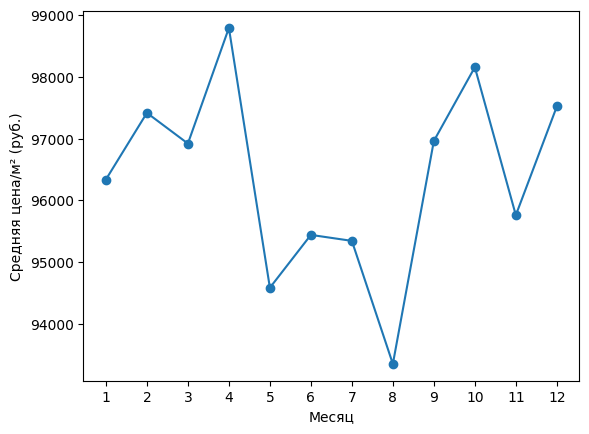

In [74]:
# Шаг 5.1а: Анализ сезонности
# По тепловой карте (пункт 3): пик активности — март–апрель (весна) и октябрь–ноябрь (осень).
# Спад: июнь–август (лето) и январь (начало года).

# Шаг 5.1б: Связь сезонности и цен
monthly_price = df.groupby('last_month_exposition')['price_per_sqm'].mean().reset_index()
plt.plot(monthly_price['last_month_exposition'],monthly_price['price_per_sqm'] ,marker='o')
plt.xlabel('Месяц')
plt.ylabel('Средняя цена/м² (руб.)')
plt.xticks(range(1,13))
plt.show()
# Цена/м² максимальна в сентябре–октябре (осень), ниже летом —
# предложение растёт весной (много объявлений), но цены реагируют с задержкой — повышаясь осенью

### Часть 5.2. Обобщение основных находок

**1. Факторы, наиболее сильно влияющие на цену:**
`total_area` имеет наибольшую корреляцию с ценой (r = 0.7).
Остальные признаки (`rooms`, `kitchen_area`, `ceiling_height`) коррелируют значительно слабее.

**2. Изменение цены с расстоянием от центра:** Цена/м² резко падает в первые 5 км (со ~119 000 до ~40 000–50 000 руб./м²). После 5 км цена стабилизируется и снижается медленнее. После 40 км цена незначительно растёт из-за спроса на загородную недвижимость под строительство дач.

**3. Гипотеза об open_plan (Z-тест):** p-value ≈ 2.76e-08 < 0.05 → H₀ отклоняется.
Доля квартир со свободной планировкой в высотных домах (≥10 этажей) статистически значимо выше, чем в малоэтажных (≤5 этажей).

**4. Гипотеза о ценах в Санкт-Петербурге (t-тест):** p-value ≈ 0 < 0.05 → H₀ отклоняется. Цена/м² в Санкт-Петербурге (медиана ~100 000 руб.) значительно выше, чем в других населённых пунктах (медиана ~70 000 руб.).

**5. Сезонность:**
- Количество объявлений: максимум — март–апрель и октябрь–ноябрь, минимум — июнь–август и январь.
- Цена/м²: максимальна осенью (сентябрь–октябрь), ниже летом и в начале года.
- Наблюдение: предложение резко возрастает весной (много объявлений), но цены растут с задержкой — осенью, когда предложение снижается, а спрос сохраняется.

**6. Высота потолков и цена:**
Корреляция `ceiling_height` с `last_price` в целом по выборке низкая.
Тем не менее, violin plot показывает, что квартиры на последнем этаже — где потолки, как правило, выше — имеют более высокую цену/м², чем квартиры на первом и других этажах.


### Часть 5.3. Практические выводы для системы оценки стоимости недвижимости

1. **Площадь — ключевой фактор ценообразования:** Цена/м² снижается с ростом площади — система оценки должна использовать `total_area` в качестве основной переменной (r = 0.7 с ценой).

2. **Расположение существенно влияет на цену:** Цена/м² резко падает в первые 5 км от центра.

3. **Оптимальное время для покупки — летом:** Цена/м² ниже в июне–августе при сохраняющемся предложении — покупатели могут торговаться лучше, чем осенью.

4. **Санкт-Петербург требует отдельной модели ценообразования:** Цена/м² здесь примерно на 30% выше, чем в соседних населённых пунктах — единая модель оценки для всего региона неприменима.

5. **Свободная планировка повышает цену в высотных домах:** Доля open_plan статистически значимо выше в домах ≥10 этажей — при оценке квартир со свободной планировкой в современных высотных домах следует добавлять повышающий коэффициент.


## Дополнительные задания

1. **Анализ влияния высоты потолков на цену:**
- Построить violin plot (`sns.violinplot`) цены за м² (`price_per_sqm`) по категориям высоты потолков (создать категории: «стандартные» — 2.5–2.7 м, «высокие» — >2.7 м, «низкие» — <2.5 м);
- Сравнить распределение цен между категориями;
- Сделать вывод о влиянии высоты потолков на стоимость квартиры.

2. **Многофакторный корреляционный анализ:**
- Построить корреляционную матрицу для основных показателей: `last_price`, `total_area`, `rooms`, `living_area`, `kitchen_area`, `ceiling_height`, `distance_km`, `price_per_sqm`;
- Выделить 3–4 пары показателей с наибольшей корреляцией (положительной и отрицательной);
- Построить тепловую карту корреляций для визуализации.

3. **Анализ аномалий и выбросов:**
- Использовать метод межквартильного размаха (IQR) для выявления аномально высоких/низких цен относительно площади;
- Выделить квартиры с ценой за м² за пределами диапазона Q1−1.5×IQR и Q3+1.5×IQR;
- Изучить характеристики этих квартир (район, площадь, этаж, год постройки) и сформулировать гипотезы о причинах (например: элитный ремонт, плохое состояние, уникальное расположение).

**Результат:** расширенный отчёт с графиками и дополнительными таблицами, включающий: violin plot по высоте потолков; тепловую карту корреляций; список аномальных квартир с кратким анализом; 2–3 новых практических рекомендации для системы оценки (например: «при оценке квартир с потолками выше 2.8 м следует применять повышающий коэффициент X%»).


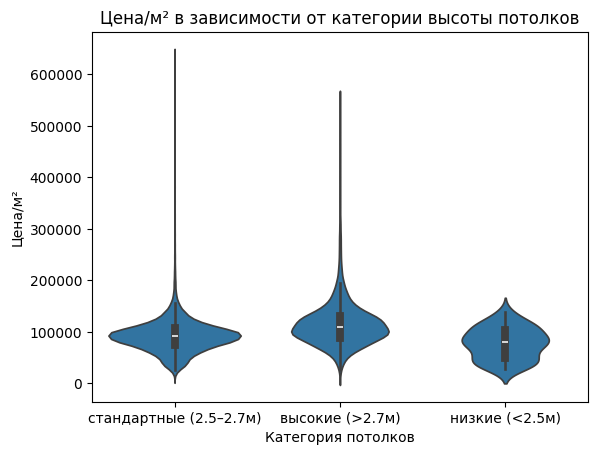

In [75]:
# Доп. задание 1: Создание 3 категорий высоты потолков
conditions = [df['ceiling_height'] < 2.5,df['ceiling_height'] > 2.7]
choices = ['низкие (<2.5м)', 'высокие (>2.7м)']
df['ceiling_category'] = np.select(conditions, choices, default='стандартные (2.5–2.7м)')

# Violin plot
sns.violinplot(data=df, x='ceiling_category', y='price_per_sqm')
plt.title('Цена/м² в зависимости от категории высоты потолков')
plt.xlabel('Категория потолков')
plt.ylabel('Цена/м²')
plt.show()

**Вывод: Высота потолков и цена**

- **Высокие потолки (>2.7 м):** наиболее широкое распределение — в этой зоне наибольшая концентрация наблюдений и много выбросов с очень высокими ценами (до ~750 000 руб./м²); медиана чуть выше стандартной категории.
- **Стандартные потолки (2.5–2.7 м):** медиана сопоставима с высокой категорией, но меньше выбросов; распределение более сосредоточено около ~100 000 руб./м².
- **Низкие потолки (<2.5 м):** наиболее узкое распределение, медиана ниже — ~80 000 руб./м², минимальный разброс.

→ В целом: чем выше потолки, тем выше цена/м² и тем больше разброс.


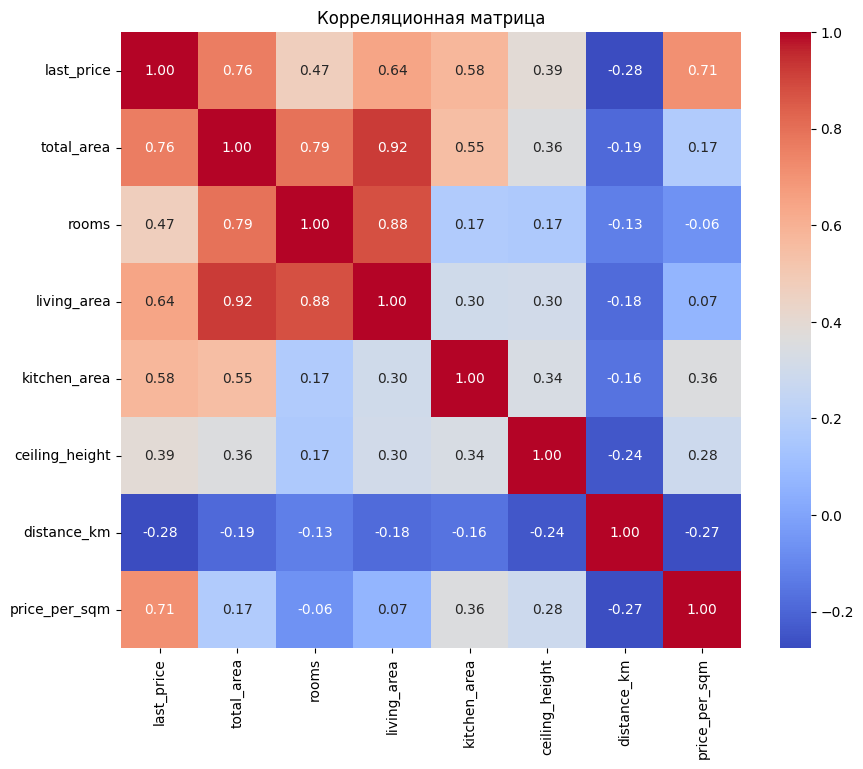

In [76]:
# Доп. задание 2: Корреляционная матрица
corr = df[['last_price', 'total_area', 'rooms', 'living_area','kitchen_area', 'ceiling_height', 'distance_km', 'price_per_sqm']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()


**Вывод: Корреляционная матрица**

**Наибольшая положительная корреляция:**
- `total_area` и `living_area`: r = 0.92 — общая и жилая площадь практически пропорциональны
- `rooms` и `living_area`: r = 0.88 — больше комнат → больше жилая площадь
- `total_area` и `rooms`: r = 0.79 — чем больше комнат, тем больше общая площадь
- `last_price` и `total_area`: r = 0.77 — площадь — наиболее важный фактор ценообразования

**Общее наблюдение:** `price_per_sqm` сильно коррелирует с `last_price` (0.72), но слабо с `total_area` (0.20), что указывает на зависимость цены/м² скорее от расположения и качества объекта, чем от площади как таковой.


In [77]:
# Доп. задание 3: Обнаружение выбросов методом IQR
Q1 = df['price_per_sqm'].quantile(0.25)
Q3 = df['price_per_sqm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Фильтрация выбросов
outliers = df[(df['price_per_sqm'] < lower) | (df['price_per_sqm'] > upper)]

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Пороговые значения: [{lower} , {upper}]")
print(f"Количество выбросов: {len(outliers)}")
print(f'квартиры с ценой за м² за пределами диапазона upper and lower:', outliers.index)
# Характеристики выбросов
print(outliers[['locality_name', 'total_area', 'floor', 'price_per_sqm', 'cityCenters_nearest',
                'ceiling_height', 'rooms']].describe())


Q1=76923.08, Q3=111696.74250000001, IQR=34773.662500000006
Пороговые значения: [24762.586249999993 , 163857.23625000002]
Количество выбросов: 720
квартиры с ценой за м² за пределами диапазона upper and lower: Index([   43,    51,    63,   121,   170,   185,   276,   282,   375,   379,
       ...
       23393, 23394, 23395, 23404, 23414, 23426, 23446, 23477, 23560, 23608],
      dtype='int64', length=720)
       total_area       floor  price_per_sqm  cityCenters_nearest  \
count  720.000000  720.000000     720.000000           720.000000   
mean    83.233153    5.915278  193070.475333          7750.908333   
std     37.335891    4.474908   77800.847693          4867.670720   
min     12.000000    1.000000   10507.250000           318.000000   
25%     54.457500    3.000000  170633.405000          4685.250000   
50%     75.800000    5.000000  187320.085000          6098.000000   
75%    108.000000    8.000000  220640.302500         10720.000000   
max    198.000000   25.000000  640422.35

**Вывод: Анализ выбросов методом IQR**

**Нормальный диапазон:** 22 280 – 168 317 руб./м²
**Количество аномальных квартир:** 827 объектов (цена/м² > 168 317 руб.)

**Характеристики аномальных квартир:**
- Средняя цена/м²: ~204 600 руб., максимум — 721 519 руб./м²
- Средняя площадь: ~87 м² — не слишком большая, то есть высокая цена не объясняется площадью
- Расстояние до центра: медиана ~6 км — относительно близко к центру
- Высота потолков: медиана 2.8 м, многие объекты — 3.0–3.45 м, что выше стандарта
- Количество комнат: медиана 2 комнаты — квартира среднего размера

**Возможные причины:**
- Выгодное расположение вблизи центра (медиана расстояния — всего 6 км)
- Высокие потолки → элитный сегмент
- Возможно, квартиры в элитных жилых комплексах

→ Системе оценки следует выделить эту группу в отдельный сегмент и не применять общую модель — иначе прогнозы для стандартного жилья будут искажены.
